# Práctica 2: word2vec / Skip-gram

## 0. Carga librerías

numpy para el cálculo numérico, pandas para mostrar tablas, matplotlib para las gráficas y Counter para contar frecuencias de palabras.

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
              
np.random.seed(42)
pd.set_option("display.max_colwidth", None)

## 1. Carga y tokenización del corpus

La **tokenización** consiste en dividir cada frase en palabras (*tokens*). Como el corpus ya viene sin signos de puntuación y con vocabulario controlado, basta con:
- pasar a minúsculas (lower) para que "El" y "el" sean la misma palabra,
- separar por espacios (split).

In [30]:
RUTA = "dataset_word2vec.txt"

with open(RUTA, encoding="utf-8") as f:
    lineas = [l.strip() for l in f if l.strip()]  

def tokenizar(frase):
    """Minúsculas + separación por espacios."""
    return frase.lower().split()

corpus = [tokenizar(l) for l in lineas]            
print("Número de frases:", len(corpus))
print("Número total de tokens:", sum(len(s) for s in corpus))
print("Ejemplo:", corpus[0])

Número de frases: 251
Número total de tokens: 1148
Ejemplo: ['el', 'perro', 'corre', 'en', 'el', 'parque']


## 2. Vocabulario

Construimos: vocab: lista ordenada de palabras **únicas**, palabra2id: diccionario palabra → índice, id2palabra: diccionario índice → palabra.

V será el tamaño del vocabulario (nº de palabras distintas).

In [31]:
frecuencias = Counter(p for frase in corpus for p in frase)

vocab = sorted(frecuencias)                        
palabra2id = {p: i for i, p in enumerate(vocab)}
id2palabra = {i: p for p, i in palabra2id.items()}
V = len(vocab)

print("Tamaño del vocabulario V =", V)
print("Palabras más frecuentes:", frecuencias.most_common(10))

Tamaño del vocabulario V = 356
Palabras más frecuentes: [('la', 131), ('el', 129), ('es', 37), ('está', 27), ('en', 26), ('un', 20), ('por', 15), ('una', 15), ('al', 14), ('gato', 11)]


## 3. Generación de pares 

Para cada palabra de una frase (la **palabra central**) tomamos las palabras que están a distancia ≤ ventana a izquierda y derecha: ese es su **contexto**. Cada pareja (centro, contexto) es un ejemplo de entrenamiento.

In [32]:
def generar_pares(corpus, ventana):
    pares = []
    for frase in corpus:
        ids = [palabra2id[p] for p in frase]
        for i, centro in enumerate(ids):
            ini = max(0, i - ventana)
            fin = min(len(ids), i + ventana + 1)
            for j in range(ini, fin):
                if j != i:                           
                    pares.append((centro, ids[j]))
    return np.array(pares)

pares = generar_pares(corpus, ventana=2)
print("\nPares totales con ventana=2:", len(pares))


Pares totales con ventana=2: 3086


## 4. El modelo Skip-gram

Arquitectura:

 palabra central (one-hot, V)  ──►  W_in (V×D)  ──►  h (D)  ──►  W_out (D×V)  ──►  softmax  ──►  P(contexto | centro)


- **W_in (V × D):** la fila *i* es el **embedding** de la palabra *i*. Multiplicar un vector one-hot por W_in equivale simplemente a *coger esa fila*.
- **W_out (D × V):** proyecta el vector oculto h a una puntuación (*logit*) por cada palabra del vocabulario.
- **Softmax:** convierte los logits en una distribución de probabilidad sobre las V palabras.
- **Pérdida:** entropía cruzada, -log P(contexto real | centro).

$$z = h\,W_{out},\quad p=\text{softmax}(z),\quad \mathcal{L}=-\log p_{o}$$

El gradiente de la entropía cruzada con softmax es muy simple: dz = p − one_hot(contexto). A partir de ahí se propaga hacia atrás a W_out y W_in. Lo implementamos a mano y lo optimizamos con **Adam** (más estable que SGD simple para un corpus tan pequeño).

> Como el vocabulario es pequeño (unos cientos de palabras), podemos usar el **softmax completo**. En corpus grandes se usa *negative sampling* o *hierarchical softmax* para evitar calcular el softmax sobre todo el vocabulario.

In [33]:
class SkipGram:
    def __init__(self, V, D, semilla=0):
        rng = np.random.default_rng(semilla)
        self.W_in  = rng.normal(0, 0.1, (V, D))      
        self.W_out = rng.normal(0, 0.1, (D, V))     
        
        self.m = [np.zeros_like(self.W_in), np.zeros_like(self.W_out)]
        self.v = [np.zeros_like(self.W_in), np.zeros_like(self.W_out)]
        self.t = 0

    def _adam(self, grads, lr, b1=0.9, b2=0.999, eps=1e-8):
        """Actualiza los pesos con el algoritmo Adam."""
        self.t += 1
        for k, (p, g) in enumerate(zip([self.W_in, self.W_out], grads)):
            self.m[k] = b1 * self.m[k] + (1 - b1) * g
            self.v[k] = b2 * self.v[k] + (1 - b2) * g * g
            m_hat = self.m[k] / (1 - b1 ** self.t)
            v_hat = self.v[k] / (1 - b2 ** self.t)
            p -= lr * m_hat / (np.sqrt(v_hat) + eps)

    def paso(self, centros, contextos, lr):
        n = len(centros)
        V = self.W_in.shape[0] 
        X = np.zeros((n, V))
        X[np.arange(n), centros] = 1
        h = X @ self.W_in                       
        z = h @ self.W_out                           
        z -= z.max(axis=1, keepdims=True)           
        p = np.exp(z)
        p /= p.sum(axis=1, keepdims=True)            
        loss = -np.log(p[np.arange(n), contextos] + 1e-12).sum()
        dz = p
        dz[np.arange(n), contextos] -= 1             
        dz /= n                                      
        g_out = h.T @ dz                             
        g_h = dz @ self.W_out.T                      
        g_in = X.T @ g_h 
        self._adam([g_in, g_out], lr)
        return loss

    @property
    def embeddings(self):
        return self.W_in


def entrenar(ventana=2, dim=30, epocas=200, lr=0.01, batch=64, semilla=0, verbose=False):
    """Entrena un Skip-gram y devuelve (modelo, historial_de_pérdida_por_época)."""
    rng = np.random.default_rng(semilla)
    pares = generar_pares(corpus, ventana)
    modelo = SkipGram(V, dim, semilla)
    historial = []
    for ep in range(epocas):
        orden = rng.permutation(len(pares))         
        total = 0.0
        for ini in range(0, len(pares), batch):
            b = pares[orden[ini:ini + batch]]
            total += modelo.paso(b[:, 0], b[:, 1], lr)
        historial.append(total / len(pares))
        if verbose and (ep % 25 == 0 or ep == epocas - 1):
            print(f"Época {ep:>3} | pérdida = {historial[-1]:.4f}")
    return modelo, historial

## 5. Entrenamiento

La **pérdida debe bajar** de forma continua. No llegará a 0: una misma palabra central tiene varios contextos posibles, así que la predicción perfecta es imposible.

Época   0 | pérdida = 5.7729
Época  25 | pérdida = 2.7990
Época  50 | pérdida = 2.7661
Época  75 | pérdida = 2.7555
Época  99 | pérdida = 2.7589


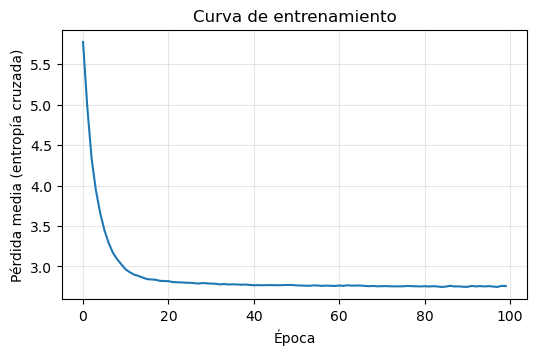

In [34]:
modelo, historial = entrenar(ventana=2, dim=30, epocas=100, lr=0.01, verbose=True)

plt.figure(figsize=(6, 3.5))
plt.plot(historial)
plt.xlabel("Época"); plt.ylabel("Pérdida media (entropía cruzada)")
plt.title("Curva de entrenamiento"); plt.grid(alpha=.3)
plt.show()

## 6. Vecinos más cercanos

Valor cercano a **1** → muy parecidas; cercano a **0** → sin relación.

In [35]:
def normalizar(E):
    return E / np.linalg.norm(E, axis=1, keepdims=True)

def vecinos(palabra, E, k=5):
    En = normalizar(E)
    sim = En @ En[palabra2id[palabra]]
    orden = np.argsort(-sim)
    return [(id2palabra[i], float(sim[i])) for i in orden if i != palabra2id[palabra]][:k]

def tabla_vecinos(palabras, E, k=5):
    filas = []
    for p in palabras:
        vs = vecinos(p, E, k)
        filas.append({"palabra": p,
                      "vecinos": ", ".join(f"{w} ({s:.2f})" for w, s in vs)})
    return pd.DataFrame(filas).set_index("palabra")

palabras_consulta = ["perro", "gata", "coche", "parís", "francia", "médico", "niña", "verano"]
tabla_vecinos(palabras_consulta, modelo.embeddings)

,vecinos
palabra,
perro,"gato (0.81), hermano (0.61), bebo (0.57), campo (0.57), patio (0.56)"
gata,"perra (0.76), mochila (0.63), gato (0.63), costa (0.60), fuente (0.59)"
coche,"conductor (0.72), cuadro (0.69), alumno (0.66), país (0.66), rápido (0.63)"
parís,"roma (0.99), madrid (0.99), españa (0.76), italia (0.75), francia (0.75)"
francia,"españa (0.99), italia (0.99), roma (0.76), país (0.76), madrid (0.75)"
médico,"enfermero (0.88), médica (0.65), hermano (0.64), escucha (0.63), maestro (0.63)"
niña,"niño (0.79), madre (0.64), escuela (0.64), revista (0.63), leer (0.61)"
verano,"alumno (0.69), profesor (0.66), invierno (0.65), lento (0.62), coche (0.61)"


## 7. Analogías

La famosa propiedad de word2vec: las relaciones semánticas se codifican como **direcciones** en el espacio vectorial. Para resolver a : b :: c : ? calculamos

$$q = v_b - v_a + v_c$$

y buscamos la palabra cuyo vector sea más parecido (coseno) a q, **excluyendo** a, b y c (si no, normalmente ganaría alguna de ellas).

Ejemplo: parís : francia :: madrid : ? → vec(francia) − vec(parís) + vec(madrid) ≈ vec(españa).

In [36]:
def analogia(a, b, c, E, k=3):
    En = normalizar(E)
    q = En[palabra2id[b]] - En[palabra2id[a]] + En[palabra2id[c]]
    q /= np.linalg.norm(q)
    sim = En @ q
    for w in (a, b, c):                             
        sim[palabra2id[w]] = -np.inf
    orden = np.argsort(-sim)[:k]
    return [(id2palabra[i], float(sim[i])) for i in orden]

consultas = [
    ("parís", "francia", "madrid"),     
    ("madrid", "españa", "roma"),       
    ("roma", "italia", "parís"),        
    ("perro", "perra", "gato"),         
    ("médico", "médica", "enfermero"), 
    ("niño", "niña", "maestro"),        
]

filas = []
for a, b, c in consultas:
    res = analogia(a, b, c, modelo.embeddings)
    filas.append({"analogía": f"{a} : {b} :: {c} : ?",
                  "top-3 (similitud)": ", ".join(f"{w} ({s:.2f})" for w, s in res)})
pd.DataFrame(filas).set_index("analogía")

,top-3 (similitud)
analogía,
parís : francia :: madrid : ?,"españa (0.98), italia (0.98), país (0.75)"
madrid : españa :: roma : ?,"italia (0.99), francia (0.99), país (0.75)"
roma : italia :: parís : ?,"españa (0.99), francia (0.98), madrid (0.76)"
perro : perra :: gato : ?,"gata (0.83), mochila (0.62), montaña (0.58)"
médico : médica :: enfermero : ?,"voy (0.83), enfermera (0.83), hermana (0.77)"
niño : niña :: maestro : ?,"historia (0.90), lección (0.88), guía (0.79)"


## 8. Influencia de los hiperparámetros

Hasta ahora hemos mirado ejemplos sueltos. Para comparar configuraciones de forma **objetiva** definimos una pequeña batería de analogías con respuesta conocida y medimos:

- **Top-1:** % de analogías donde la respuesta correcta es la primera candidata.
- **Top-3:** % donde aparece entre las 3 primeras.
- **Pérdida final** de entrenamiento.

Hacemos tres experimentos variando **un solo hiperparámetro cada vez** (el resto en su valor base: ventana=2, dim=30, epocas=200, lr=0.01).

Como el entrenamiento depende de la inicialización aleatoria y el corpus es muy pequeño, **cada configuración se entrena con 3 semillas distintas y se promedian los resultados** (así una racha de suerte no engaña). Esta celda tarda unos minutos.

In [37]:
EVAL = [
    ("parís", "francia", "madrid", "españa"),
    ("madrid", "españa", "roma", "italia"),
    ("roma", "italia", "parís", "francia"),
    ("perro", "perra", "gato", "gata"),
    ("gato", "gata", "perro", "perra"),
    ("niño", "niña", "maestro", "maestra"),
    ("médico", "médica", "enfermero", "enfermera"),
    ("panadero", "panadera", "cocinero", "cocinera"),
    ("pintor", "pintora", "jardinero", "jardinera"),
    ("camarero", "camarera", "conductor", "conductora"),
    ("ingeniero", "ingeniera", "programador", "programadora"),
    ("padre", "madre", "hermano", "hermana"),
    ("alumno", "alumna", "profesor", "profesora"),
    ("abuelo", "abuela", "rey", "reina"),
]

assert all(w in palabra2id for fila in EVAL for w in fila), "Hay palabras fuera del vocabulario"

def evaluar(E):
    top1 = top3 = 0
    for a, b, c, esperado in EVAL:
        cand = [w for w, _ in analogia(a, b, c, E, k=3)]
        top1 += cand[0] == esperado
        top3 += esperado in cand
    return top1 / len(EVAL), top3 / len(EVAL)

def experimento(nombre, valores, semillas=(0, 1, 2), **fijos):
    filas = []
    for val in valores:
        params = dict(ventana=2, dim=30, epocas=200, lr=0.01)
        params.update(fijos)
        params[nombre] = val
        res = []
        for s in semillas:
            m, hist = entrenar(semilla=s, **params)
            t1, t3 = evaluar(m.embeddings)
            res.append((hist[-1], t1, t3))
        perd, t1, t3 = np.mean(res, axis=0)
        filas.append({nombre: val, "pérdida final": round(perd, 3),
                      "top-1": f"{t1:.0%}", "top-3": f"{t3:.0%}"})
    return pd.DataFrame(filas).set_index(nombre)

### 8.1 Tamaño de la ventana

In [38]:
res_ventana = experimento("ventana", [1, 2, 3, 5])
res_ventana

,pérdida final,top-1,top-3
ventana,,,
1,2.187,71%,86%
2,2.749,71%,93%
3,2.983,71%,86%
5,3.093,67%,88%


### 8.2 Dimensión del embedding

In [39]:
res_dim = experimento("dim", [2, 5, 10, 30, 100])
res_dim

,pérdida final,top-1,top-3
dim,,,
2,4.313,7%,17%
5,3.334,43%,76%
10,2.751,62%,81%
30,2.749,71%,93%
100,2.821,71%,93%


### 8.3 Número de épocas

In [40]:
res_ep = experimento("epocas", [5, 20, 50, 200])
res_ep

,pérdida final,top-1,top-3
epocas,,,
5,3.676,60%,79%
20,2.823,74%,93%
50,2.772,74%,93%
200,2.749,71%,93%


### 8.4 Learning rate

In [41]:
res_lr = experimento("lr", [0.001, 0.01, 0.05, 0.2])
res_lr

,pérdida final,top-1,top-3
lr,,,
0.001,2.599,76%,90%
0.010,2.749,71%,93%
0.050,3.331,50%,76%
0.200,6.736,2%,7%


## 9. Conclusiones

**Hiperparámetros:**
* **Learning rate:** El rango óptimo es 0.001–0.01 (~70-76% de acierto Top-1). Con valores altos (0.2) el modelo diverge porque los pesos saltan sin llegar a asentarse.
* **Dimensión del embedding:** El rendimiento se estabiliza entre 10 y 30 dimensiones. Subir a 100 no aporta mejoras porque un corpus tan pequeño (~1150 tokens) no tiene información suficiente para aprovecharla.
* **Épocas:** El modelo converge alrededor de las 100 épocas. Iterar más no disminuye la pérdida y aumenta el riesgo de que el modelo simplemente memorice los pares.
* **Tamaño de la ventana:** Su impacto es menor debido a que las frases son muy cortas. Ventanas pequeñas (1-2) capturan mejor la sintaxis (relaciones locales), mientras que las más grandes aportan contexto temático a costa de introducir más ruido.

**Resultados:**
* **Fortalezas:** El modelo acierta fácilmente relaciones como género o capital-país gracias a que comparten estructuras repetitivas en el texto.
* **Limitaciones del corpus:** Palabras que aparecen en contextos idénticos (ej. España e Italia) son difíciles de desempatar en las analogías. Además, palabras con una sola aparición (ej. "maestra") fallan por falta de entrenamiento.
* **Ruido en vecinos:** El modelo agrupa a veces palabras que comparten estructura gramatical pero no significado real.